In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("faresashraf1001/supermarket-sales")

print("Path to dataset files:", path)


Path to dataset files: C:\Users\modis\.cache\kagglehub\datasets\faresashraf1001\supermarket-sales\versions\2


In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r"C:\Users\modis\.cache\kagglehub\datasets\faresashraf1001\supermarket-sales\versions\2\SuperMarket Analysis.csv")

1. Koks yra pardavimų (total) vidurkis ir mediana?

In [4]:
df.shape

(1000, 17)

In [5]:
df.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='str')

In [6]:
mean = df["Sales"].mean()
print(mean)


322.966749


In [7]:
median = df["Sales"].median()
print(median)

253.848


2. Kuris padalinys (branch) turi didžiausius vidutinius pardavimus? Parodyti grafiškai

In [8]:
mean_by_branch = df.groupby("Branch")["Sales"].mean()
print(mean_by_branch)


Branch
Alex     312.354031
Cairo    319.872506
Giza     337.099715
Name: Sales, dtype: float64


In [9]:
mean_by_branch.idxmax()



'Giza'

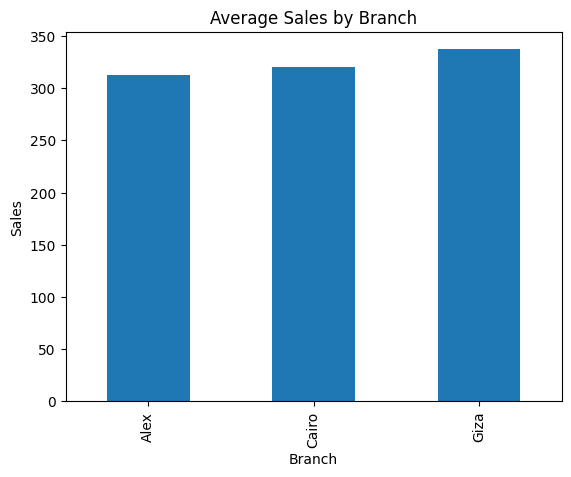

In [10]:
mean_by_branch.plot.bar()
plt.title("Average Sales by Branch")
plt.ylabel("Sales")
plt.show()


3. Kokie yra diapazonai ir IQR vieneto kainos(unit price)?

In [11]:
min = df["Unit price"].min()
max = df["Unit price"].max()
range = max - min
print("Min =", min,
      "Max =", max,
      "Range =", range)

Min = 10.08 Max = 99.96 Range = 89.88


In [12]:
q1 = df["Unit price"].quantile(0.25)
print(q1)

32.875


In [13]:
q3 = df["Unit price"].quantile(0.75)
print(q3)

77.935


In [14]:
iqr = q3 - q1
print(iqr)

45.06


4. Patikrinti ar yra nuokrypių duomenyse. Pavaizduoti pardavimų nuokrypius su
boxplot

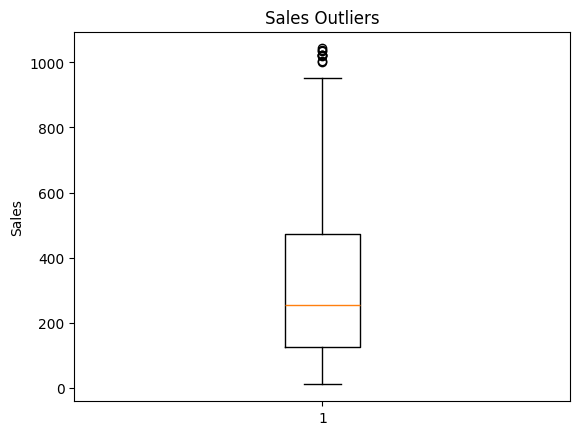

In [15]:
plt.boxplot(df["Sales"])
plt.title("Sales Outliers")
plt.ylabel("Sales")
plt.show()


5. Koks dažniausiai naudojamas atsiskaitymo būdas(payment)?

In [16]:
most_common_payment = df["Payment"].mode()
print("Dazniausiai naudojamas atsiskaitymo budas:", most_common_payment)

Dazniausiai naudojamas atsiskaitymo budas: 0    Ewallet
Name: Payment, dtype: str


6. Kokie vidutiniai pardavimai pagal kategorijas(Product line)?

In [17]:
df.groupby("Product line")["Sales"].mean()

Product line
Electronic accessories    319.632538
Fashion accessories       305.089298
Food and beverages        322.671517
Health and beauty         323.643020
Home and lifestyle        336.636956
Sports and travel         332.065220
Name: Sales, dtype: float64

7. Kurio tipo klientų pardavimų mediana yra didesnė? (customer type)

In [18]:
df.groupby("Customer type")["Sales"].median()

Customer type
Member    271.950
Normal    225.792
Name: Sales, dtype: float64

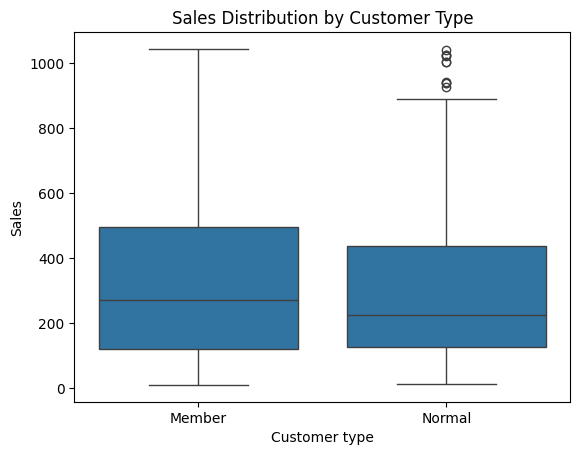

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="Customer type", y="Sales", data=df)
plt.title("Sales Distribution by Customer Type")
plt.show()
